<a href="https://colab.research.google.com/github/Shivanikumarijha07/UTCI/blob/RS-and-GIS/Universal_Thermal_Climate_Index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install --upgrade xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.1/472.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.6 MB/s eta 0:00:00
  Attempting uninstall: earthengine-api
    Found existing installation: earthengine-api 1.5.24
    Uninstalling earthengine-api-1.5.24:
      Successfully uninstalled earthengine-api-1.5.24


In [4]:
!pip install -U geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.8 MB/s eta 0:00:00
  Attempting uninstall: geemap
    Found existing installation: geemap 0.35.3
    Uninstalling geemap-0.35.3:
      Successfully uninstalled geemap-0.35.3


In [5]:
import ee

In [6]:
ee.Authenticate()
ee.Initialize(
    project ="practical-1-469320",
    opt_url= 'https://earthengine-highvolume.googleapis.com'
)

In [7]:
import geemap

In [8]:
map= geemap.Map()
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [10]:
roi=map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          74.267443,
                          12.082296
                        ],
                        [
                          73.784261,
                          14.43468
                        ],
                        [
                          73.828125,
                          16.594081
                        ],
                        [
                          75.849514,
                          17.644022
                        ],
                        [
                          77.299615,
                          19.103648
                        ],
                        [
                          78.442722,
                          17.811456
                        ],
                        [
                          78.178738,
                          17.14079
                        ],
                        [
                          78.090834,
                          16.678293
                        ],
                        [
                          77.476033,
                          14.562318
                        ],
                        [
                          79.057644,
                          13.880746
                        ],
                        [
                          78.486654,
                          11.652236
                        ],
                        [
                          74.267443,
                          12.082296
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [11]:
fldas=(
    ee.ImageCollection("NASA/FLDAS/NOAH01/C/GL/M/V001")
    .filterDate("2024","2025")
    .select(["Tair_f_tavg", "Wind_f_tavg", "Qair_f_tavg","RadT_tavg"],
            ["tas","sfcWind", "hurs", "mrt"])
    .map(
        lambda img: img.select("sfcWind", "hurs").addBands(
            img.select("tas","mrt").subtract(273.15)
        )
    )
)

fldas

In [12]:
import xarray as xr
import matplotlib.pyplot as plt


In [13]:
ds= xr.open_dataset(
    fldas,
    engine ="ee",
    crs="EPSG:4326",
    scale = 0.11,
    geometry= roi
)

In [14]:
ds = ds.sortby("time")*1
tas= "Near surface air temperature"

Text(0.5, 1.02, 'Near surface air temperature (Karnataka, India)')

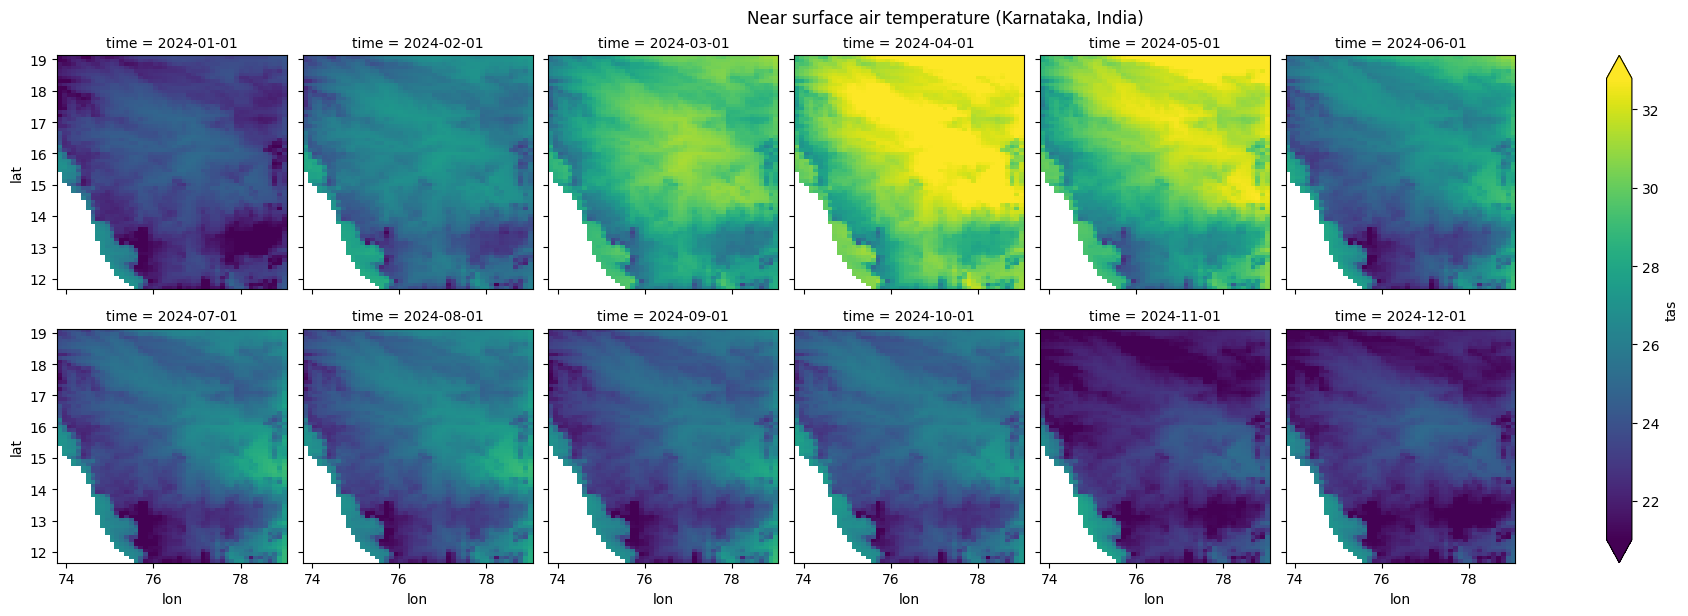

In [15]:
m= ds.tas.plot(
    x = "lon",
    y = "lat",
    col = "time",
    col_wrap = 6,
    robust = True,
)
m.fig.suptitle("Near surface air temperature (Karnataka, India)", y=1.02)


In [16]:
!pip install xclim

In [17]:
from xclim.indicators.convert import universal_thermal_climate_index

In [18]:
tas = ds.tas
tas.attrs["units"] = "degC"
hurs = ds.hurs
hurs.attrs["units"] = ""
sfcWind= ds.sfcWind
sfcWind.attrs["units"] = "m/s"
mrt= ds.mrt
mrt.attrs["units"] = "degC"
mrt

<xarray.DataArray 'mrt' (time: 12, lon: 48, lat: 68)> Size: 157kB
array([[[      nan,       nan,       nan, ..., 22.011683, 21.31695 ,
         21.41598 ],
        [      nan,       nan,       nan, ..., 21.763056, 21.507135,
         21.857874],
        [      nan,       nan,       nan, ..., 21.849634, 22.00265 ,
         22.157099],
        ...,
        [22.493921, 22.325953, 21.407434, ..., 24.62948 , 24.81048 ,
         24.923487],
        [24.225   , 24.240534, 23.206415, ..., 24.46264 , 24.613916,
         24.91543 ],
        [24.758448, 24.566797, 24.525537, ..., 24.640589, 24.761408,
         24.8724  ]],

       [[      nan,       nan,       nan, ..., 24.910181, 24.218012,
         24.341944],
        [      nan,       nan,       nan, ..., 24.729425, 24.498468,
         24.860315],
        [      nan,       nan,       nan, ..., 24.870935, 25.039667,
         25.216852],
...
        [22.667841, 22.501154, 21.652094, ..., 22.34344 , 22.477777,
         22.55337 ],
        [24.568232, 24.449518, 23.425867, ..., 22.35995 , 22.438135,
         22.692347],
        [25.314661, 25.138605, 24.994806, ..., 22.808283, 22.905298,
         22.898767]],

       [[      nan,       nan,       nan, ..., 21.15603 , 20.420008,
         20.474451],
        [      nan,       nan,       nan, ..., 20.839502, 20.553766,
         20.887903],
        [      nan,       nan,       nan, ..., 20.885828, 20.999018,
         21.14123 ],
        ...,
        [22.467554, 22.311518, 21.288385, ..., 22.990778, 23.135218,
         23.206354],
        [24.057825, 23.999231, 23.015558, ..., 22.975824, 23.06814 ,
         23.332788],
        [24.562067, 24.447168, 24.354944, ..., 23.343378, 23.473505,
         23.496332]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 96B 2024-01-01 2024-02-01 ... 2024-12-01
  * lon      (lon) float64 384B 73.84 73.95 74.06 74.17 ... 78.79 78.9 79.01
  * lat      (lat) float64 544B 11.71 11.82 11.93 12.04 ... 18.86 18.97 19.08
Attributes:
    id:             mrt
    data_type:      {'type': 'PixelType', 'precision': 'double'}
    crs:            EPSG:4326
    crs_transform:  [0.1, 0, -180, 0, -0.1, 90]
    units:          degC

In [19]:
utci= universal_thermal_climate_index(
    tas= tas,
    hurs= hurs,
    sfcWind= sfcWind,
    mrt= mrt
)

In [22]:
utci_cel = utci-273.15
utci_cel.attrs["units"] = "degC"
utci_cel


<xarray.DataArray 'utci' (time: 12, lon: 48, lat: 68)> Size: 313kB
array([[[        nan,         nan,         nan, ..., 14.89372132,
         13.95409355, 14.13852043],
        [        nan,         nan,         nan, ..., 14.55482848,
         14.24657985, 14.76984381],
        [        nan,         nan,         nan, ..., 14.67085496,
         14.86265098, 15.12921847],
        ...,
        [13.50149023, 13.37766984, 12.86682917, ..., 18.22629813,
         18.37739948, 18.49051083],
        [16.64557656, 16.75625304, 15.38114825, ..., 18.23396387,
         18.35822815, 18.6292911 ],
        [17.38875324, 17.27244933, 17.25624983, ..., 18.78916376,
         18.8884099 , 18.96636862]],

       [[        nan,         nan,         nan, ..., 18.08645974,
         17.17184267, 17.33133986],
        [        nan,         nan,         nan, ..., 17.75938844,
         17.45481228, 17.93939186],
        [        nan,         nan,         nan, ..., 17.86996609,
         18.04342414, 18.28590325],
...
        [14.48928606, 14.31453316, 13.7724259 , ..., 15.96289119,
         16.02172654, 16.13582821],
        [17.67543519, 17.71160908, 16.27614972, ..., 16.0408881 ,
         16.04863138, 16.31365041],
        [18.45854311, 18.3122875 , 18.23276683, ..., 16.72392024,
         16.68998351, 16.71097196]],

       [[        nan,         nan,         nan, ..., 13.32356048,
         12.25830133, 12.36041113],
        [        nan,         nan,         nan, ..., 12.95878429,
         12.55396795, 13.01889772],
        [        nan,         nan,         nan, ..., 13.09443971,
         13.20659092, 13.4119792 ],
        ...,
        [14.42708552, 14.22434889, 13.58832765, ..., 15.94393888,
         15.9785531 , 16.0123083 ],
        [17.39209717, 17.42069276, 15.99100928, ..., 16.02954359,
         16.02213615, 16.21906478],
        [17.95851   , 17.82085601, 17.73582892, ..., 16.72801981,
         16.70144137, 16.66972305]]])
Coordinates:
  * time     (time) datetime64[ns] 96B 2024-01-01 2024-02-01 ... 2024-12-01
  * lon      (lon) float64 384B 73.84 73.95 74.06 74.17 ... 78.79 78.9 79.01
  * lat      (lat) float64 544B 11.71 11.82 11.93 12.04 ... 18.86 18.97 19.08
Attributes:
    units:           degC
    units_metadata:  temperature: unknown
    cell_methods:    
    history:         [2025-12-17 11:01:02] utci: UTCI(tas=tas, hurs=hurs, sfc...
    long_name:       Universal thermal climate index (utci)
    description:     Utci is the equivalent temperature for the environment d...

Text(0.5, 1.02, 'Universal Thermal Climate Index (Karnataka, India)')

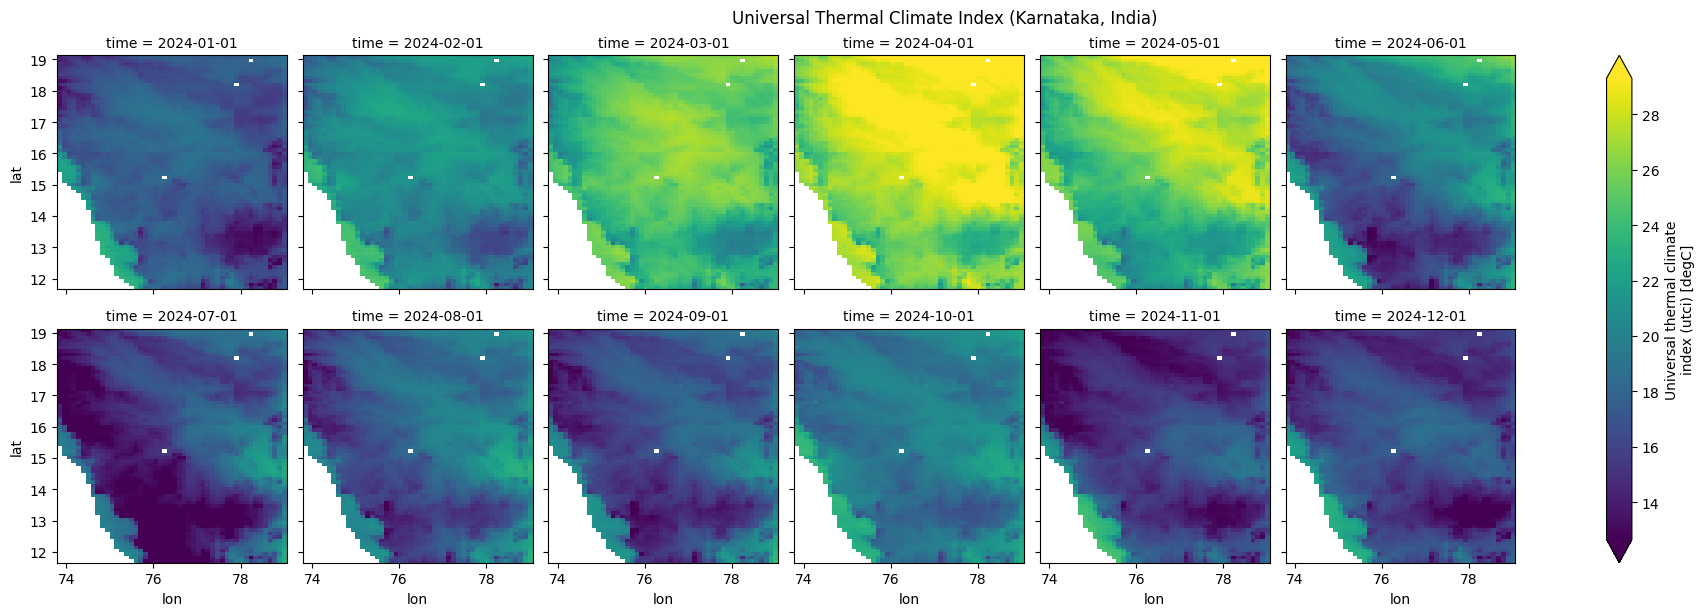

In [23]:
g= utci_cel.plot(
    x = "lon",
    y = "lat",
    col = "time",
    col_wrap = 6,
    robust = True
)
g.fig.suptitle("Universal Thermal Climate Index (Karnataka, India)", y=1.02)